# Phase 3: Hybrid Fusion Model — Training & Evaluation

This notebook trains and evaluates the **Hybrid Attention-Weighted Fusion Model (Model C)**,
which combines EfficientNet-B3 + CBAM deep features with Phase 1 handcrafted features
(color histogram, LBP, GLCM) via a learned attention gate.

## Architecture Summary

```
cnn_embed  = EfficientNet-B3+CBAM features   (B, 1536)
ml_features = Phase 1 handcrafted features    (B, 154)
combined   = concat([cnn_embed, ml_features]) (B, 1690)
alpha      = sigmoid(attn_layer(combined))    (B, 512) — learned gate
cnn_proj   = cnn_projection(cnn_embed)        (B, 512)
ml_proj    = ml_projection(ml_features)       (B, 512)
fused      = alpha * cnn_proj + (1-alpha) * ml_proj
output     = classifier(fused)                (B, 6)
```

**Key Innovation**: The attention gate learns per-sample which stream to trust.
For texture-heavy conditions (eczema), α → ML stream. For complex patterns, α → CNN stream.

### ⚡ Crash-Safe Training
Training saves a **full checkpoint every epoch** (model + optimizer + scheduler state).
If the notebook disconnects:
1. Re-run the setup cells (1-3)
2. Run Section 4 — it will **automatically resume** from the last completed epoch
3. No training progress is lost

## 0. Environment Setup (Colab / Local)

In [15]:
# Mount Google Drive (Colab only — skip if running locally)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('✅ Google Drive mounted')
except ImportError:
    IN_COLAB = False
    print('ℹ️  Not in Colab — skipping drive mount')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


In [16]:
import sys
import os
from pathlib import Path

# Auto-detect project root (works in Colab and locally)
colab_path = Path('/content/drive/MyDrive/Hybrid-Dermatologist')

if colab_path.exists():
    project_root = colab_path
else:
    project_root = Path(os.getcwd()).resolve()
    if project_root.name == 'phase3':
        project_root = project_root.parents[1]

project_path = str(project_root)
if project_root.exists():
    os.chdir(project_path)
    if project_path not in sys.path:
        sys.path.insert(0, project_path)
    print(f'✅ Working directory: {os.getcwd()}')
else:
    print(f'❌ Project root not found at {project_path}')

✅ Working directory: /content/drive/MyDrive/Hybrid-Dermatologist


In [17]:
# Install dependencies (Colab only)
import subprocess
packages = ['timm', 'scikit-learn', 'torchvision', 'scikit-image', 'grad-cam']
for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f'✅ {package}')
    except ImportError:
        print(f'📦 Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f'✅ {package} installed')

✅ timm
📦 Installing scikit-learn...
✅ scikit-learn installed
✅ torchvision
📦 Installing scikit-image...
✅ scikit-image installed
📦 Installing grad-cam...
✅ grad-cam installed


In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from src.skin_analysis.phase3.config import Phase3Config
from src.skin_analysis.phase3.model_c import HybridFusionModel
from src.skin_analysis.phase3.dataset import build_hybrid_dataloaders, compute_class_weights
from src.skin_analysis.phase3.train_c import train_hybrid, seed_everything, detect_device

seed_everything(42)
device = detect_device()
print(f'Device: {device}')
print(f'✅ All imports successful')

Device: cuda
✅ All imports successful


## 1. Configuration

In [19]:
cfg = Phase3Config()

# Ensure output directories exist
cfg.output_dir.mkdir(parents=True, exist_ok=True)
cfg.feature_cache_dir.mkdir(parents=True, exist_ok=True)

print(f'CNN feature dim: {cfg.cnn_feature_dim}')
print(f'ML feature dim:  {cfg.ml_feature_dim}')
print(f'Fusion dim:      {cfg.fusion_hidden_dim}')
print(f'Stage 1 epochs:  {cfg.epochs_stage1} (lr={cfg.lr_stage1})')
print(f'Stage 2 epochs:  {cfg.epochs_stage2} (lr={cfg.lr_stage2_head})')
print(f'Classes:         {cfg.class_names}')
print(f'Output dir:      {cfg.output_dir}')
print(f'\nCheckpoint path: {cfg.output_dir / "checkpoint_hybrid.pth"}')
if (cfg.output_dir / 'checkpoint_hybrid.pth').exists():
    ckpt = torch.load(cfg.output_dir / 'checkpoint_hybrid.pth', map_location='cpu', weights_only=False)
    print(f'  ↻ EXISTING CHECKPOINT FOUND!')
    print(f'    Stage: {ckpt.get("stage", "?")}')
    print(f'    Epoch: {ckpt.get("epoch", "?")}')
    print(f'    Best F1: {ckpt.get("best_f1", 0):.4f}')
    print(f'    History length: {len(ckpt.get("history", []))} epochs')
    print(f'  Training will RESUME from this checkpoint automatically.')
else:
    print(f'  No checkpoint found — training will start from scratch.')

CNN feature dim: 1536
ML feature dim:  154
Fusion dim:      512
Stage 1 epochs:  10 (lr=0.001)
Stage 2 epochs:  25 (lr=0.0001)
Classes:         ('acne', 'dark_spots', 'eczema', 'normal', 'rosacea', 'wrinkles')
Output dir:      outputs/phase3_hybrid

Checkpoint path: outputs/phase3_hybrid/checkpoint_hybrid.pth
  No checkpoint found — training will start from scratch.


## 2. Data Loading

Train samples: 7879
Val samples:   944


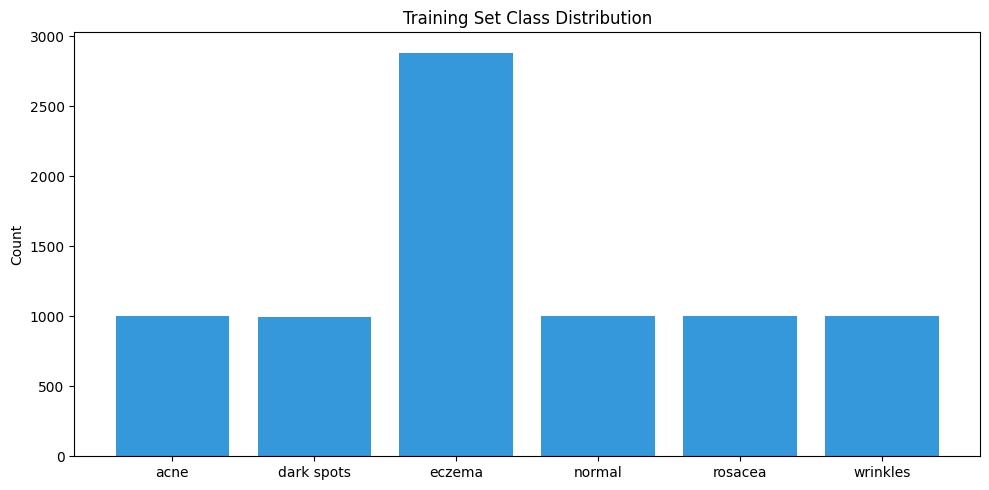


Image tensor shape:  torch.Size([3, 300, 300])
ML feature shape:    torch.Size([154])
Label: 3 (normal)


In [20]:
train_loader, val_loader, train_dataset, val_dataset = build_hybrid_dataloaders(cfg)
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples:   {len(val_dataset)}')

# Class distribution
labels = train_dataset.get_labels()
class_counts = {}
for label in labels:
    class_counts[label] = class_counts.get(label, 0) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cfg.display_names, [class_counts.get(i, 0) for i in range(6)], color='#3498db')
ax.set_ylabel('Count')
ax.set_title('Training Set Class Distribution')
plt.tight_layout()
plt.show()

# Verify dual-stream output
img, ml_feat, label = train_dataset[0]
print(f'\nImage tensor shape:  {img.shape}')
print(f'ML feature shape:    {ml_feat.shape}')
print(f'Label: {label} ({cfg.class_names[label]})')

## 3. Model Architecture

In [21]:
class_weights = compute_class_weights(train_dataset)
print(f'Class weights: {class_weights}')

model = HybridFusionModel.from_phase2_checkpoint(
    checkpoint_path=cfg.phase2_checkpoint,
    num_classes=cfg.num_classes,
    ml_feature_dim=cfg.ml_feature_dim,
    fusion_hidden_dim=cfg.fusion_hidden_dim,
    dropout=cfg.dropout,
    device=device,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Print architecture summary
print(f'\nArchitecture:')
print(f'  CNN Backbone: EfficientNet-B3 + CBAM ({cfg.cnn_feature_dim} dims)')
print(f'  ML Features:  Color(96) + LBP(26) + GLCM(32) = {cfg.ml_feature_dim} dims')
print(f'  Fusion:       Attention-weighted ({cfg.fusion_hidden_dim} dims)')
print(f'  Classifier:   {cfg.fusion_hidden_dim}→{cfg.fusion_hidden_dim//2}→{cfg.num_classes}')

Class weights: tensor([1.3132, 1.3184, 0.4555, 1.3132, 1.3132, 1.3132])
  Loaded Phase 2 checkpoint: outputs/phase2_deep_learning/best_model_phase2.pth
Total parameters:     13,910,934
Trainable parameters: 13,910,934

Architecture:
  CNN Backbone: EfficientNet-B3 + CBAM (1536 dims)
  ML Features:  Color(96) + LBP(26) + GLCM(32) = 154 dims
  Fusion:       Attention-weighted (512 dims)
  Classifier:   512→256→6


## 4. Training (auto-resumes from checkpoint)

**If Colab disconnects:** just re-run cells 0-3 above, then re-run this cell.
Training will automatically pick up from the last saved epoch — no progress is lost.

Every epoch saves:
- `checkpoint_hybrid.pth` → full state (model + optimizer + scheduler + history)
- `best_model_hybrid.pth` → best weights only (for inference)

In [ ]:
history = train_hybrid(
    model, train_loader, val_loader, cfg,
    class_weights=class_weights,
    device=device,
)


╔══ Stage 1: Training fusion layers (CNN backbone frozen) ══╗

  Epoch 1/10  (lr=0.001000)


  train:   0%|          | 0/246 [00:00<?, ?it/s]

  val  :   0%|          | 0/30 [00:00<?, ?it/s]

  train_loss=0.6872  train_acc=0.8810  val_loss=0.9611  val_acc=0.7966  val_f1_w=0.7947  val_f1_m=0.7945
  ✓ New best val_f1=0.7947

  Epoch 2/10  (lr=0.000905)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

  val  :   0%|          | 0/30 [00:00<?, ?it/s]

  train_loss=0.5449  train_acc=0.9538  val_loss=0.9104  val_acc=0.8294  val_f1_w=0.8296  val_f1_m=0.8174

  Epoch 5/10  (lr=0.000095)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  train:   0%|          | 0/246 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bea1d3758a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bea1d3758a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

## 4b. Check Checkpoint Status

Run this cell anytime to see where training stands.

In [2]:
ckpt_path = cfg.output_dir / 'checkpoint_hybrid.pth'
best_path = cfg.output_dir / 'best_model_hybrid.pth'
hist_path = cfg.output_dir / 'training_history.csv'

print('=== Checkpoint Status ===')
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    print(f'  Stage:        {ckpt.get("stage", "?")}')
    print(f'  Epoch:        {ckpt.get("epoch", "?")}')
    print(f'  Best F1:      {ckpt.get("best_f1", 0):.4f}')
    h = ckpt.get('history', [])
    print(f'  Epochs done:  {len(h)}')
    if h:
        last = h[-1]
        print(f'  Last epoch:   Stage {last["stage"]}, Epoch {last["epoch"]}')
        print(f'    val_acc:    {last["val_acc"]:.4f}')
        print(f'    val_f1_w:   {last["val_f1_weighted"]:.4f}')
        print(f'    val_f1_m:   {last["val_f1_macro"]:.4f}')
    has_optim = 'optimizer_state_dict' in ckpt
    has_sched = 'scheduler_state_dict' in ckpt
    print(f'  Has optimizer state: {"✅" if has_optim else "❌"}')
    print(f'  Has scheduler state: {"✅" if has_sched else "❌"}')
else:
    print('  No checkpoint found.')

print(f'\n  Best model exists: {"✅" if best_path.exists() else "❌"}')
print(f'  History CSV exists: {"✅" if hist_path.exists() else "❌"}')

NameError: name 'cfg' is not defined

## 5. Learning Curves

In [ ]:
# Load history from checkpoint or variable
if 'history' not in dir() or not history:
    # Try loading from checkpoint
    ckpt_path = cfg.output_dir / 'checkpoint_hybrid.pth'
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        history = ckpt.get('history', [])
        print(f'Loaded history from checkpoint ({len(history)} epochs)')
    else:
        # Try CSV
        hist_csv = cfg.output_dir / 'training_history.csv'
        if hist_csv.exists():
            df = pd.read_csv(hist_csv)
            history = df.to_dict('records')
            print(f'Loaded history from CSV ({len(history)} epochs)')
        else:
            print('No training history found. Run Section 4 first.')
            history = []

if history:
    df = pd.DataFrame(history)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(df['epoch'], df['train_loss'], label='Train', linewidth=2)
    axes[0].plot(df['epoch'], df['val_loss'], label='Val', linewidth=2)
    axes[0].axvline(x=cfg.epochs_stage1, color='gray', linestyle='--', alpha=0.5, label='Stage transition')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(df['epoch'], df['train_acc'], label='Train', linewidth=2)
    axes[1].plot(df['epoch'], df['val_acc'], label='Val', linewidth=2)
    axes[1].axvline(x=cfg.epochs_stage1, color='gray', linestyle='--', alpha=0.5, label='Stage transition')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # F1 Score
    axes[2].plot(df['epoch'], df['val_f1_weighted'], label='F1 Weighted', linewidth=2)
    axes[2].plot(df['epoch'], df['val_f1_macro'], label='F1 Macro', linewidth=2)
    axes[2].axvline(x=cfg.epochs_stage1, color='gray', linestyle='--', alpha=0.5, label='Stage transition')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title('Validation F1 Scores')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Hybrid Fusion Model — Learning Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(cfg.output_dir / 'learning_curves_hybrid.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print best metrics
    best_idx = df['val_f1_weighted'].idxmax()
    print(f"\nBest epoch: {df.loc[best_idx, 'epoch']}")
    print(f"  Val Loss:       {df.loc[best_idx, 'val_loss']:.4f}")
    print(f"  Val Accuracy:   {df.loc[best_idx, 'val_acc']:.4f}")
    print(f"  Val F1 Weighted: {df.loc[best_idx, 'val_f1_weighted']:.4f}")
    print(f"  Val F1 Macro:    {df.loc[best_idx, 'val_f1_macro']:.4f}")

## 6. Evaluation — Confusion Matrix & Classification Report

In [ ]:
from src.skin_analysis.phase3.evaluate_all import (
    predict_hybrid, save_confusion_matrix, save_classification_report
)

# Load best model
best_ckpt = cfg.output_dir / 'best_model_hybrid.pth'
if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
    print(f'✅ Loaded best model from {best_ckpt}')
else:
    print('⚠️  No best model found — using current model state')
model = model.to(device)

preds, labels, confs, probs = predict_hybrid(model, val_loader, device)

# Confusion matrix
save_confusion_matrix(labels, preds, cfg.display_names, cfg.output_dir, 'hybrid_fusion')

# Classification report
report = save_classification_report(labels, preds, cfg.display_names, cfg.output_dir, 'hybrid_fusion')

# Display report
from sklearn.metrics import classification_report
print(classification_report(labels, preds, target_names=list(cfg.display_names)))

## 7. Attention Weight Analysis

Examining the learned attention gate α to understand which stream the model trusts per class.

In [ ]:
# Collect attention weights for analysis
all_alphas = []
all_labels_attn = []

model.eval()
with torch.no_grad():
    for images, ml_features, labels_batch in val_loader:
        images = images.to(device)
        ml_features = ml_features.to(device)
        alpha = model.get_attention_weights(images, ml_features)
        all_alphas.append(alpha.cpu().numpy())
        all_labels_attn.extend(labels_batch.tolist())

all_alphas = np.concatenate(all_alphas, axis=0)  # (N, 512)
mean_alpha_per_sample = all_alphas.mean(axis=1)   # (N,)

# Mean attention weight per class
fig, ax = plt.subplots(figsize=(10, 5))
class_alphas = []
for cls_idx, cls_name in enumerate(cfg.display_names):
    mask = np.array(all_labels_attn) == cls_idx
    class_alphas.append(mean_alpha_per_sample[mask].mean())

bars = ax.bar(cfg.display_names, class_alphas, color='#2ecc71', edgecolor='black')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Equal weight (α=0.5)')
ax.set_ylabel('Mean α (higher = trusts CNN more)')
ax.set_title('Attention Gate: CNN vs ML Trust per Class\n(α > 0.5 = CNN dominant, α < 0.5 = ML dominant)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(cfg.output_dir / 'attention_weights_per_class.png', dpi=150)
plt.show()

for name, alpha_val in zip(cfg.display_names, class_alphas):
    stream = 'CNN' if alpha_val > 0.5 else 'ML'
    print(f'  {name:>12}: α = {alpha_val:.3f} → {stream} dominant')